# Morphological Transformations

Morphological Transformations are a type of [convolution operation](https://github.com/ankurjay/opencv-python-tutorials/blob/main/02%20Basic%20Image%20Processing/02_Smoothing_Images.ipynb) on images. They are normally performed on binary images. A **kernel** (also called Structuring Element) needs to be defined, which decides the nature of operation on the image. This kernel is then convolved over the image to perform that operation.

In binary images, we call the HIGH/WHITE/1 value as 'foreground', and the LOW/BLACK/0 value as 'background'.

Two basic morphological operations are **Erosion** and **Dilation**. There are variants to these like Opening, Closing, Gradient, etc.


In this tutorial we will cover the following:
* Constructing the Structuring Element (Kernel)
* Erosion
* Dilation
* Opening
* Closing
* Morphological Gradient
* Top Hat Transforms
* Hit-or-Miss
* Thinning, Thickening, Skeletonization (TODO)

We also go through an interesting Exercise:
* Extracting Musical Notes from a Music Sheet


---

## Standard Imports

In [111]:
import cv2
import numpy as np
from tutorial_utils.utils import *
from matplotlib import pyplot as plt
DATA_DIR = data_dir()

---

## Constructing the Structuring Element (Kernel)

For Morphological operations, Kernels are typically binary - they are represented as matrices composed only of 0 and 1. Therefore, they are like [masks](https://github.com/ankurjay/opencv-python-tutorials/blob/main/01%20Core%20Operations/03_Arithmetic_Operations.ipynb).

We can manually create a structuring element (kernel) using `numpy`. For example, a square kernel of size 5x5 can be defined using

        kernel = np.ones( (5,5), np.uint8 )

Alternatively, OpenCV provides the function `cv2.getStructuringElement()` for some standard kernel shapes. It takes as arguments:
* Kernel Shape
    * `cv2.MORPH_RECT`
        * Useful for processing images with **sharp edges** and rectangular features
    * `cv2.MORPH_CROSS`
        * Useful for targeting **thin lines** (horizontal/vertical) or dealing with features that have a 4-connected neighborhood
    * `cv2.MORPH_ELLIPSE`
        * Useful for working with **round objects** or when you need the resulting boundaries to be smooth and curved, not 'blocky'.
* Kernel Size, specified as (width, height)
* anchor (optional) : Anchor position within the element. The default value is (-1,-1) meaning that the anchor is at the center. Note that only the shape of a cross-shaped structure depends on the anchor position. In other cases the anchor regulates how much the result of the morphology operation is shifted.

**NOTE**: OpenCV's documentation mentions the kernel shape `MORPH_DIAMOND`, but it is not included as part of the OpenCV library as of version 4.9.0. 

---

### Examples

In [2]:
# Rectangular Kernel
print("Rectangular Kernel : \n")
print(cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))

# Elliptical Kernel
print("\nElliptical Kernel : \n")
print(cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)))


# Cross-Shaped Kernel
print("\nCross-Shaped Kernel : \n")
print(cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5)))



Rectangular Kernel : 

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

Elliptical Kernel : 

[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]

Cross-Shaped Kernel : 

[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]


---

## Erosion

Erosion means being 'eaten away from the outside'; an erosion operation eats away the boundaries of the foreground object. 

As the kernel slides over the image, a pixel in the original image (either 0 or 1) will be considered 1 only if **all** the pixels under the kernel is 1. Otherwise it is eroded (made to 0).

At boundaries, some pixels under the kernel will belong to the foreground, and some to the background. As a result, pixels on or near the boundary are all converted into background (zero-ed) depending on the size of the kernel. So the thickness or size of the foreground / white region decreases in the image. 

This is useful for removing small white noises, or detaching two connected objects. 'White noise' in a binary image means noisy white dots on the background.

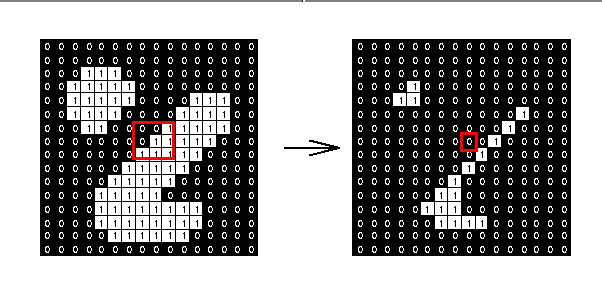

OpenCV provides `cv2.erode()` for this operation. It takes as arguments:
* Input image
* Kernel
* Number of iterations (of convolutions to be performed on the image)

---

### Example

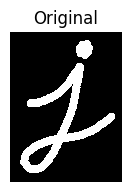

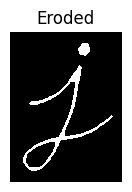

In [3]:
img = cv2.imread(DATA_DIR + "j.png", cv2.IMREAD_GRAYSCALE)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

erosion = cv2.erode(img, kernel, iterations=1)

cv2_imshow(img, "Original")
cv2_imshow(erosion, "Eroded")

---

## Dilation

Dilation is the opposite of Erosion - it bloats / expands the boundaries of the foreground object.

As the kernel slides over the image, a pixel in the original image (either 0 or 1) will be set to 1 if **any** of the pixels under the kernel is 1. Otherwise it is left as 0.

We know erosion helps remove white noise from an image, but it also shrinks the foreground object. Typically, this is where we use dilation - to grow the eroded object back. Dilation is also useful in joining broken parts of the foreground.

OpenCV provides `cv2.dilate()` for this operation. It takes as arguments:
* Input image
* Kernel
* Number of iterations (of convolutions to be performed on the image)

---

### Example

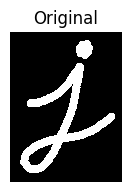

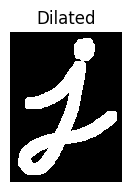

In [4]:
img = cv2.imread(DATA_DIR + "j.png", cv2.IMREAD_GRAYSCALE)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

dilation = cv2.dilate(img, kernel, iterations=1)

cv2_imshow(img, "Original")
cv2_imshow(dilation, "Dilated")

---

## Variants of Erosion and Dilation

OpenCV provides a convenient `cv2.morphologyEx()` function that lets us do some operations that are variants of Erosion and Dilation. This function takes in the following arguments:
* Input Image
* Flag that dictates the type of operation
* Kernel

---

### Opening

Opening is another name for **Erosion followed by Dilation**. OpenCV provides the `cv2.MORPH_OPEN` flag to use with `morphologyEx`. The same kernel is used for all operations.

It is useful for removing white noise (i.e. white dots in the *background*). 

---

#### Example

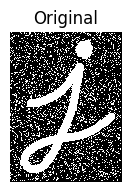

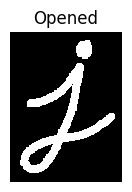

In [5]:
img = cv2.imread(DATA_DIR + "j.png", cv2.IMREAD_GRAYSCALE)
noisy_img = add_snp_noise(img, method='salt') # See tutorial_utils/utils.py

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

opening = cv2.morphologyEx(noisy_img, cv2.MORPH_OPEN, kernel)

cv2_imshow(noisy_img, "Original")
cv2_imshow(opening, "Opened")

---

### Closing

Closing is the reverse of Opening. It performs **Dilation followed by Erosion**. OpenCV provides the `cv2.MORPH_CLOSE` flag to use with `morphologyEx`. The same kernel is used for all operations.

It is used for removing 'holes' in the *foreground* i.e. 'black/pepper noise'

---

#### Example

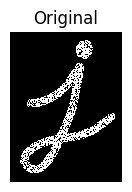

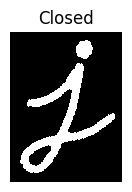

In [6]:
img = cv2.imread(DATA_DIR + "j.png", cv2.IMREAD_GRAYSCALE)
noisy_img = add_snp_noise(img, amount=0.3, method='pepper') # See tutorial_utils/utils.py

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

closing = cv2.morphologyEx(noisy_img, cv2.MORPH_CLOSE, kernel)

cv2_imshow(noisy_img, "Original")
cv2_imshow(closing, "Closed")

---

### Morphological Gradient

This is the **difference between the Dilation and Erosion** of an image. The result looks like the **outline of the foreground**.

---

#### Example

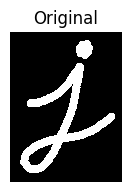

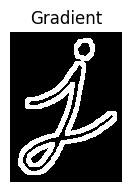

In [7]:
img = cv2.imread(DATA_DIR + "j.png", cv2.IMREAD_GRAYSCALE)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

cv2_imshow(img, "Original")
cv2_imshow(grad, "Gradient")

---

### Top-Hat Transforms

Top-Hat transforms are used to:
1. Extract small, bright features from a dark background. This is called **White Top-Hat Transform**
2. Extract small, dark features from a bright background. This is called **Black Top-Hat Transform**

To be more specific, these transforms return an image, containing the 'objects'/'elements' of the input image that are **smaller than the kernel / structural element**. 

Another way to think about it is : Suppose we used an opening or closing operation to remove noise. This 'noise' is typically smaller than the kernel. So a top-hat transform would return an image containing only this 'noise'. 

* White Top-Hat Transform : Difference between Input Image and the Opening of that Input Image
* Black Top-Hat Transform : Difference between Closing of an Input Image, and the Input Image

OpenCV provides `cv2.MORPH_TOPHAT` flag for white top-hat transforms, and `cv2.MORPH_BLACKHAT` for black top-hat transforms, to be used with `morphologyEx`.

---

#### Example 1 of White Top-Hat Transform

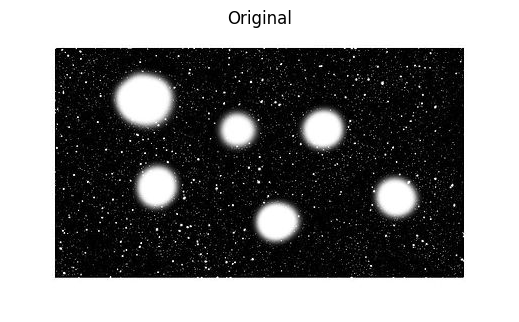

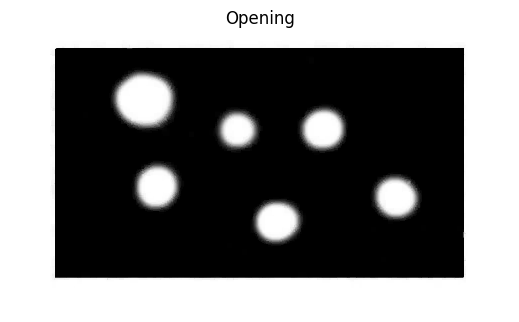

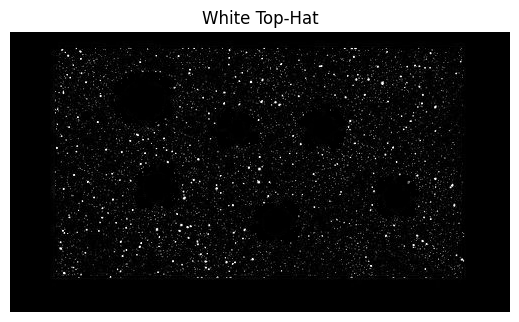

In [8]:
img = cv2.imread(DATA_DIR + "cosmos.jpg")
cv2_imshow(img, "Original")

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
cv2_imshow(opening, "Opening")

white_tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
cv2_imshow(white_tophat, "White Top-Hat")

---

#### Example 2 of White Top-Hat Transform

In this example, we don't have a noisy image, but we have a somewhat large kernel. Due to that, most pixels in the foreground cannot 'fill' the kernel completely (therefore are considered 'smaller than the kernel'), hence there is a lot of erosion. 

The dilation that follows the erosion operation doesn't have enough information to reconstruct the original, therefore we are left with three white patches in the Opening of the image. Every other portion of the foreground is treated like white/salt noise. This is why in the Top-Hat version, we see the entire foreground, minus those three patches. 

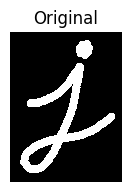

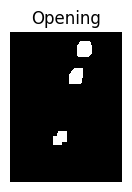

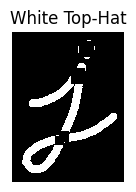

In [9]:
img = cv2.imread(DATA_DIR + "j.png")
cv2_imshow(img, "Original")

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9,9))

opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
cv2_imshow(opening, "Opening")

white_tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
cv2_imshow(white_tophat, "White Top-Hat")

---

#### Example 1 of Black Top-Hat Transform

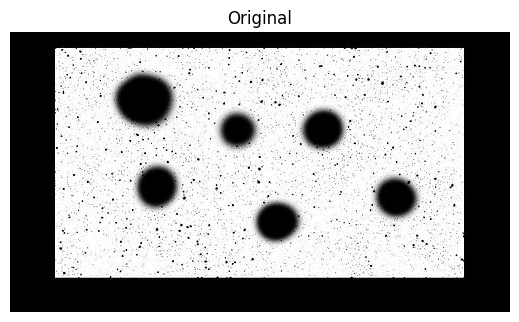

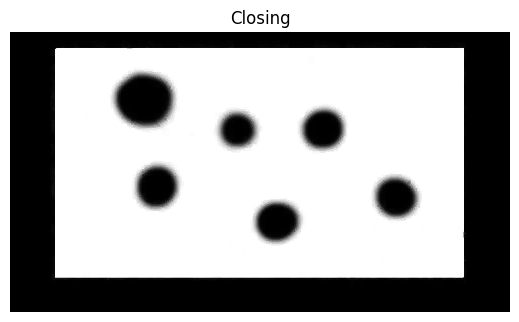

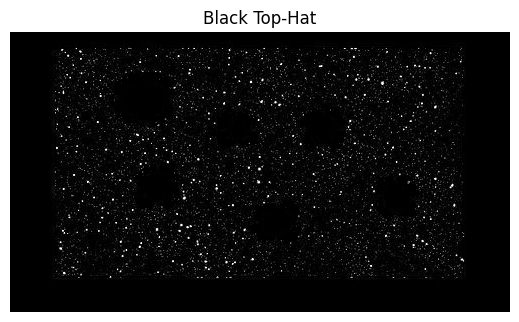

In [10]:
img = cv2.imread(DATA_DIR + "cosmos.jpg")
img = cv2.bitwise_not(img)
cv2_imshow(img, "Original")

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
cv2_imshow(closing, "Closing")

black_tophat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
cv2_imshow(black_tophat, "Black Top-Hat")

---

### Hit-or-Miss Transform

The Hit-or-Miss transformation is useful to **find patterns in binary images**. In particular, it finds those pixels whose neighborhood matches the shape of a first kernel / structuring element $B_{1}$, while not matching the shape of a second kernel $B_{2}$ at the same time. 

When we say 'a pixel's neighborhood pixels match the shape of a kernel', this is an **erosion** operation.

Therefore, the hit-or-miss operation comprises three steps:

1. Erode image with kernel $B_{1}$
2. Erode the *complement of image* (bitwise not) with kernel $B_{2}$
3. AND the results of Step 1 and Step 2

Instead of doing two erosion operations, we find that the structuring element $B_{1}$ and $B_{2}$ can be combined into a single element $B$ that can then be convolved on the image in one operation.

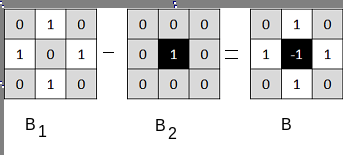

How does this work?
* If we want a particular pixel in the pattern to be in the foreground, we represent that pixel by `1`
* If we want a particular pixel in the pattern to be in the background, we represent that pixel by  `-1`
* If we don't care if a pixel at a given position in the pattern belongs to the foreground or background, we represent it as `0`
* Suppose in the above composition, element @ (row=0,col=1) was marked `1` in both $B_{1}$ and $B_{2}$  then it doesn't matter whether that element belongs to the foreground or background, in $B$, so its value is `0`.
* Hence, we can think of `B` being the result of the subtraction operation `B = B1 - B2`

---

#### Example

In the below image, we can see that only one pixel matches the kernel pattern where the left,right,top and bottom pixels belong to the foreground, and central pixel belongs to the background.

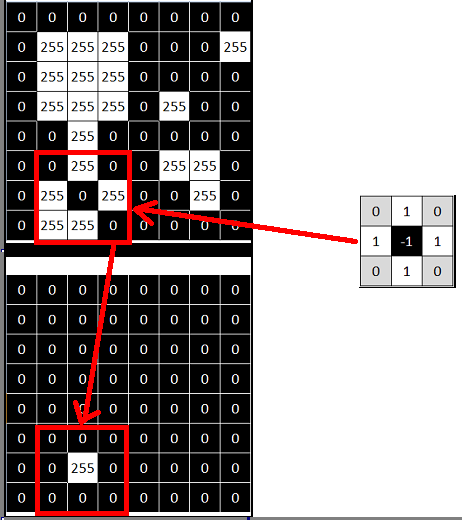

---

#### Example (In Code)



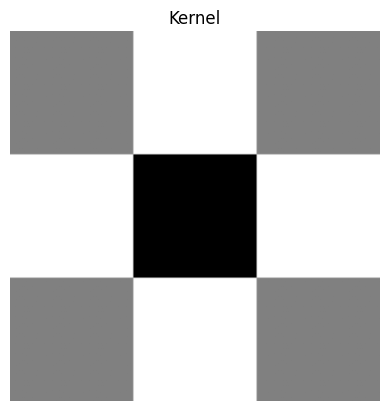

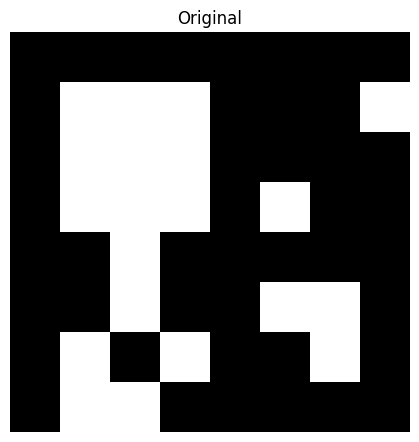

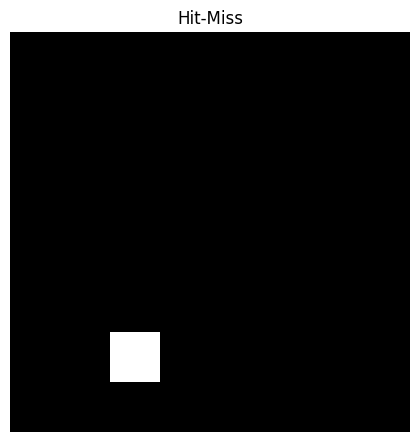

In [20]:
# Input image (8x8 matrix of unsigned 8-bit integers)
img = np.array([
    [0,   0,   0,   0,   0,   0,   0,   0],
    [0, 255, 255, 255,   0,   0,   0, 255],
    [0, 255, 255, 255,   0,   0,   0,   0],
    [0, 255, 255, 255,   0, 255,   0,   0],
    [0,   0, 255,   0,   0,   0,   0,   0],
    [0,   0, 255,   0,   0, 255, 255,   0],
    [0, 255,   0, 255,   0,   0, 255,   0],
    [0, 255, 255, 0,   0,   0,   0,   0]
], dtype=np.uint8)

# Kernel (3x3 matrix of integers)
kernel = np.array([
    [0,  1,  0],
    [1, -1,  1],
    [0,  1,  0]
], dtype=int)

hitmiss = cv2.morphologyEx(img, cv2.MORPH_HITMISS, kernel)

# Resize images proportionately so we can see what's going on
block_kernel = np.ones((50,50), dtype=np.uint8)
img = np.kron(img, block_kernel)
kernel = np.kron(kernel, block_kernel)
hitmiss = np.kron(hitmiss, block_kernel)

# Show the kernel
plt.imshow(kernel, cmap='gray')
plt.title("Kernel")
plt.axis('off')

# Display the images
cv2_imshow(img, "Original")
cv2_imshow(hitmiss, "Hit-Miss")

---

### Thickening, Thinning, Skeletonization

TODO, WIP

---

## Additional References

See [Morphological Operations](http://homepages.inf.ed.ac.uk/rbf/HIPR2/morops.htm)

---

## Exercise : Extracting Musical Notes from Music Sheet

In this simple exercise we apply Dilation and Erosion with a custom kernel to extract music notes from a music sheet.

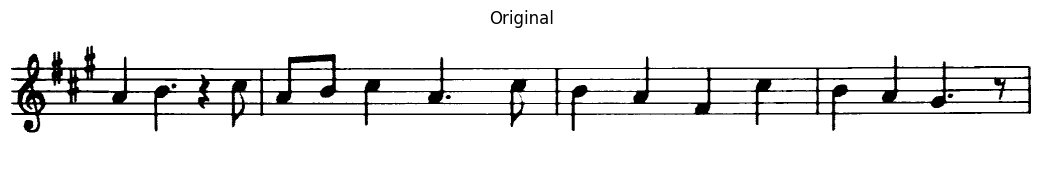

In [138]:
# Step 1 : Load image as Grayscale
img = cv2.imread(DATA_DIR + "music_notes.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.shape != 2 else img

cv2_imshow(img, "Original")

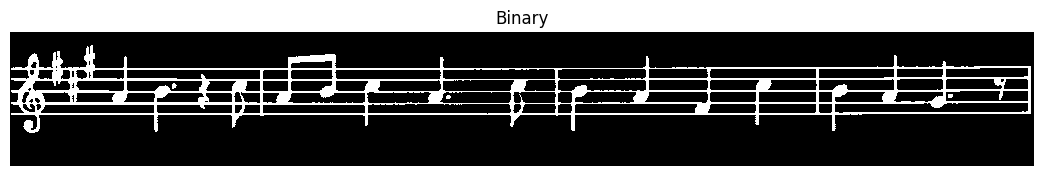

In [139]:
# Step 2: Convert Grayscale to Binary Image using Adaptive Thresholding
gray = cv2.bitwise_not(img)
bw = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, -2)
cv2_imshow(bw, "Binary")

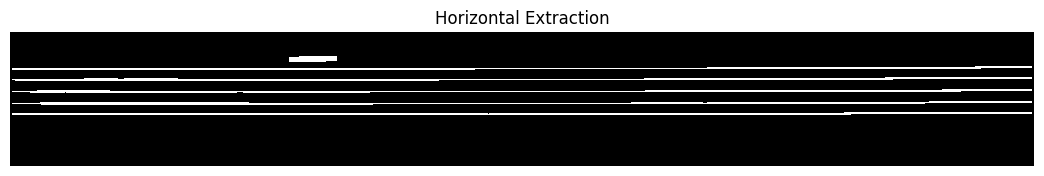

In [140]:
# Step 3 : Create copies of the image to extract horizontal and vertical features
horizontal = np.copy(bw)
vertical = np.copy(bw)

# Step 4 : Make Horizontal Kernel 
cols = horizontal.shape[1]
horizontal_size = cols // 30
horizontalStructure = cv2.getStructuringElement(cv2.MORPH_RECT, (horizontal_size, 1))

# Step 5 : Apply morphology operations
horizontal = cv2.erode(horizontal, horizontalStructure)
horizontal = cv2.dilate(horizontal, horizontalStructure)

cv2_imshow(horizontal, "Horizontal Extraction")

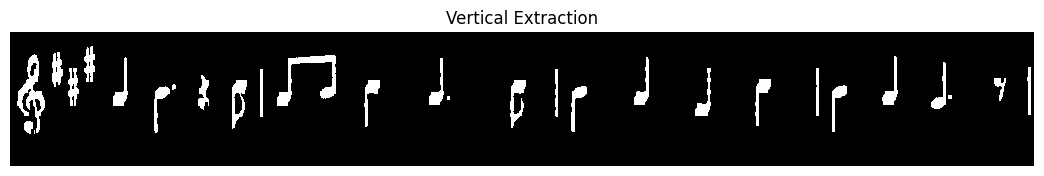

In [141]:
# Step 6 : Make Vertical Kernel 
rows = horizontal.shape[0]
vertical_size = rows // 30
verticalStructure = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vertical_size))

# Step 7 : Apply morphology operations
vertical = cv2.erode(vertical, verticalStructure)
vertical = cv2.dilate(vertical, verticalStructure)

cv2_imshow(vertical, "Vertical Extraction")

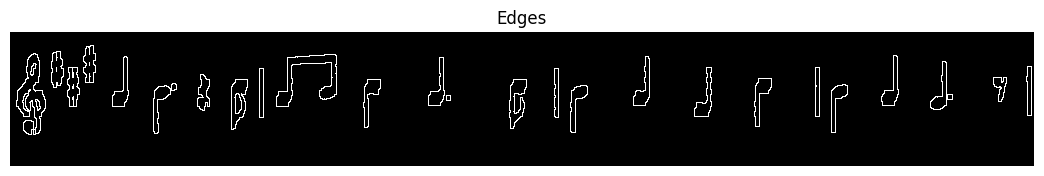

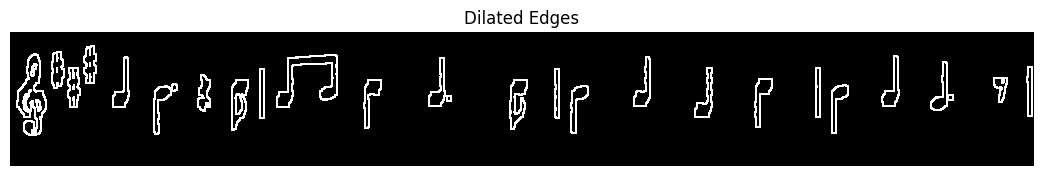

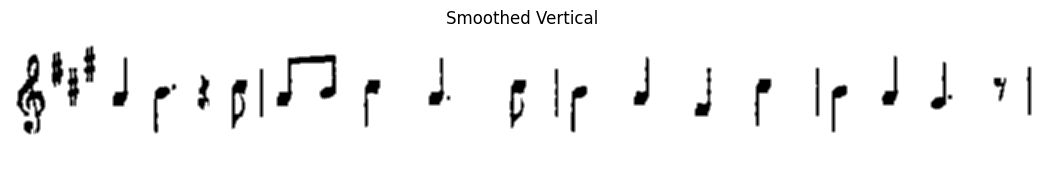

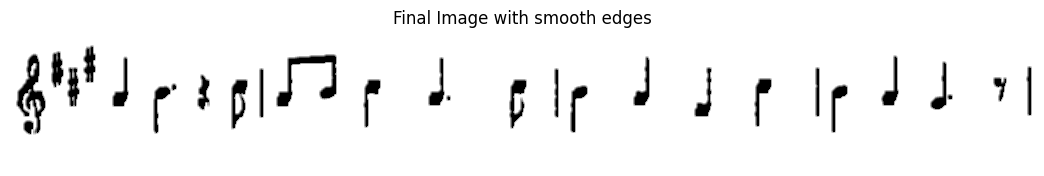

In [142]:
# Step 8 : Refine Edges

# Invert image back to original state
vertical = cv2.bitwise_not(vertical)

# Do adaptive thresholding to get edges
edges = cv2.adaptiveThreshold(vertical, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 3, -2)
cv2_imshow(edges, "Edges")

# Dilate the edges
kernel = np.ones((2,2), np.uint8)
edges = cv2.dilate(edges, kernel)
cv2_imshow(edges, "Dilated Edges")

# Smooth vertical using Blur
smooth = np.copy(vertical)
smooth = cv2.blur(smooth, (3,3))
cv2_imshow(smooth, "Smoothed Vertical")

# Select the dilated edges
(rows, cols) = np.where(edges != 0)

# From the smoothed vertical, copy the smoothed pixels corresponding to the dilated edges into
# the inverted vertical image
vertical[rows, cols] = smooth[rows, cols]
cv2_imshow(vertical, "Final Image with smooth edges")
